# Primera interacción con los videos

In [1]:
import supervision as sv
from ultralytics.models.sam import SAM3SemanticPredictor
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO, SAM
import torch
import os

print(f"Supervision versión: {sv.__version__}")

c:\Users\IGNITER\anaconda3\envs\supervision\Lib\site-packages\supervision\annotators\core.py:11: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.interpolate import splev, splprep


Supervision versión: 0.28.0


In [3]:
import cv2

cap = cv2.VideoCapture("../VideosEjemplo/Cesar_mod.mov")
print("¿Video abierto?:", cap.isOpened())

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

print(f"FPS: {fps}")
print(f"Total frames: {int(total_frames)}")
print(f"Duración: {total_frames/fps:.1f} segundos")
print(f"Resolución: {int(width)} x {int(height)} px")

cap.release()

¿Video abierto?: True
FPS: 59.70695970695971
Total frames: 489
Duración: 8.2 segundos
Resolución: 1360 x 1808 px


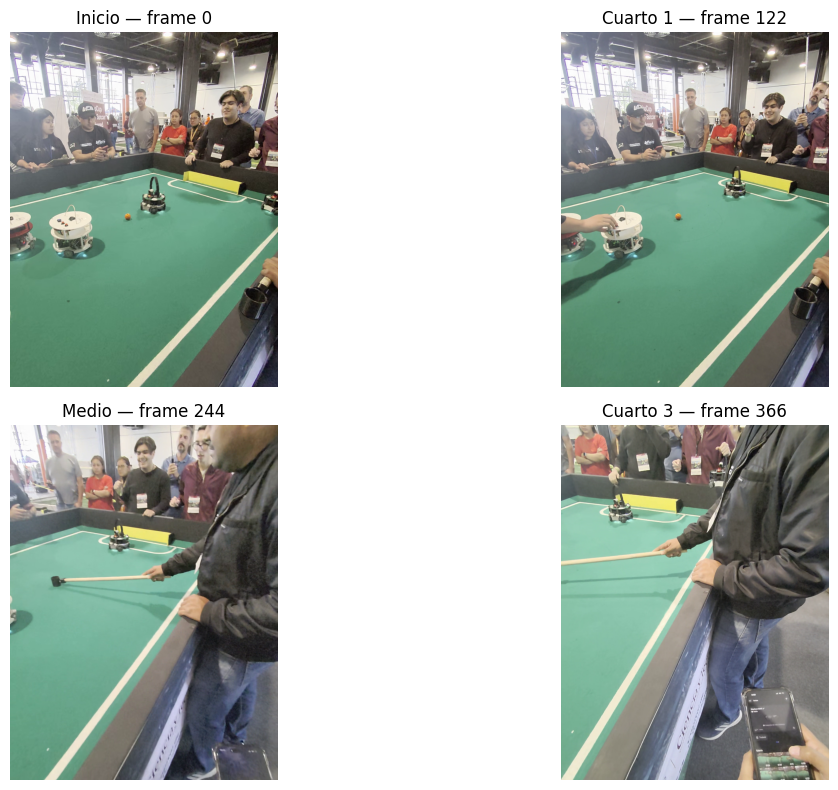

In [4]:
import matplotlib.pyplot as plt
import cv2

cap = cv2.VideoCapture("../VideosEjemplo/Cesar_mod.mov")
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

# Tomar 4 momentos distintos del partido
momentos = [0, int(total_frames * 0.25), int(total_frames * 0.5), int(total_frames * 0.75)]
titulos = ["Inicio", "Cuarto 1", "Medio", "Cuarto 3"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, frame_num in enumerate(momentos):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"{titulos[i]} — frame {frame_num}")
        axes[i].axis("off")

plt.tight_layout()
plt.show()
cap.release()

In [5]:
cap = cv2.VideoCapture("../VideosEjemplo/Cesar_mod.mov")
cap.set(cv2.CAP_PROP_POS_FRAMES, momentos[1])
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

model = YOLO("yolov8m.pt")
results = model(frame_rgb)

detections = sv.Detections.from_ultralytics(results[0])
print(detections)


0: 640x512 10 persons, 1 sports ball, 47.4ms
Speed: 5.8ms preprocess, 47.4ms inference, 22.2ms postprocess per image at shape (1, 3, 640, 512)
Detections(xyxy=array([[     592.38,      287.46,      754.51,      620.84],
       [     918.66,      310.85,      1198.8,      677.37],
       [     278.96,      358.48,      531.06,      670.51],
       [     752.93,      387.89,      892.22,      633.71],
       [     1.0074,      380.66,      278.62,      720.89],
       [     881.21,      396.34,       984.4,      641.72],
       [      577.7,      925.54,      614.05,      962.37],
       [    0.45728,      924.41,      293.42,      1033.2],
       [     1166.1,      282.14,      1358.2,      713.69],
       [     988.72,      410.92,      1028.4,      454.75],
       [     1229.4,      284.52,      1357.8,      713.59]], dtype=float32), mask=None, confidence=array([    0.90638,      0.9054,     0.89991,     0.88382,      0.7851,     0.77642,     0.71601,     0.60952,     0.36315,     0.

## Segmentación con SAM3

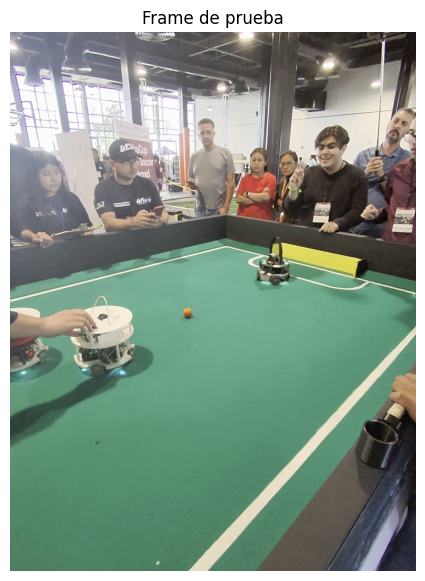

Frame guardado en assets/frame_prueba.jpg


In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Usa tu ruta correcta
ruta_video = "../VideosEjemplo/Cesar_mod.mov"

cap = cv2.VideoCapture(ruta_video)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Tomar un frame del primer cuarto donde haya acción
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 4)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Guardarlo para usarlo con SAM 3
cv2.imwrite("assets/frame_prueba.jpg", cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title("Frame de prueba")
plt.axis("off")
plt.show()

print("Frame guardado en assets/frame_prueba.jpg")

In [7]:
import cv2
image = cv2.imread("assets/frame_prueba.jpg")
yolo_model = YOLO("yolov8n.pt")
yolo_results = yolo_model(image)[0]
yolo_detections = sv.Detections.from_ultralytics(yolo_results)

print(f"YOLO detectó {len(yolo_detections)} objetos")


0: 640x512 10 persons, 1 sports ball, 28.0ms
Speed: 2.3ms preprocess, 28.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)
YOLO detectó 11 objetos


In [8]:
sam_model = SAM("sam3.pt")

In [9]:
overrides = dict(conf=0.50, task="segment", mode="predict", model="sam3.pt")
if torch.cuda.is_available():
    overrides["half"] = True   # FP16 solo en GPU

predictor = SAM3SemanticPredictor(overrides=overrides)
print("Predictor listo")

Predictor listo


In [10]:
predictor.set_image(image)

resultados = predictor(text=["robot", "ball"])[0]
detections = sv.Detections.from_ultralytics(resultados)

print(f"Objetos encontrados: {len(detections)}")
print(f"¿Tiene máscaras?    {detections.mask is not None}")

Ultralytics 8.4.56  Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050, 8151MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 3 robots, 1 ball, 373.2ms
Speed: 3.2ms preprocess, 373.2ms inference, 18.2ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-8
Objetos encontrados: 4
¿Tiene máscaras?    True


### Visualización de frame con sam

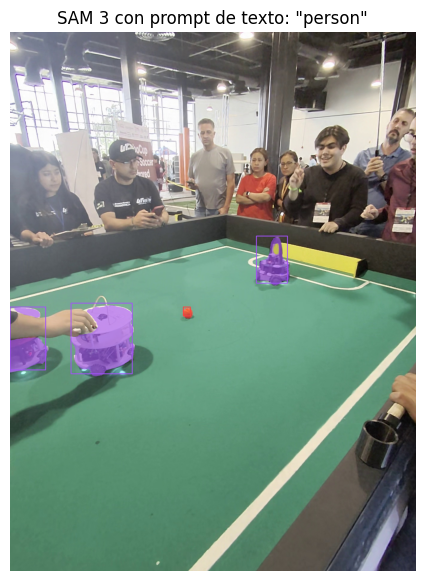

In [11]:
box_annotator  = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator(opacity=0.6)

annotated = mask_annotator.annotate(scene=image.copy(), detections=detections)
annotated = box_annotator.annotate(scene=annotated,    detections=detections)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title('SAM 3 con prompt de texto: "person"')
plt.show()

### Visualizar el video con las mascaras

In [12]:
video_path = "../VideosEjemplo/gael.mov"
cap = cv2.VideoCapture(video_path)

In [ ]:
from ultralytics.models.sam import SAM3SemanticPredictor

# Inicializar anotadores
mask_annotator  = sv.MaskAnnotator(opacity=0.6)
label_annotator = sv.LabelAnnotator()
box_annotator   = sv.BoxAnnotator()

# Inicializar el tracker de supervision
tracker = sv.ByteTrack()

# Inicializar predictor SAM3
overrides = dict(conf=0.50, task="segment", mode="predict", model="sam3.pt")
if torch.cuda.is_available():
    overrides["half"] = True

predictor_video = SAM3SemanticPredictor(overrides=overrides)

def procesar_frame_sam(frame: np.ndarray, _: int) -> np.ndarray:
    predictor_video.set_image(frame)
    resultados_frame = predictor_video(text=["small robot", "orange ball"])[0]
    detections = sv.Detections.from_ultralytics(resultados_frame)

    if len(detections) == 0:
        return frame

    # Actualizar tracker con las detecciones del frame actual
    detections = tracker.update_with_detections(detections)

    # Construir etiquetas
    labels = [
        f"ID:{tid}"
        for tid in detections.tracker_id
    ] if detections.tracker_id is not None else []

    # Anotar
    annotated = mask_annotator.annotate(scene=frame.copy(), detections=detections)
    annotated = box_annotator.annotate(scene=annotated, detections=detections)
    if labels:
        annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    return annotated


sv.process_video(
    source_path=video_path,
    target_path="assets/Primera_prueba_robot_sam.mp4",
    callback=procesar_frame_sam
)
print("Guardado: assets/Primera_prueba_robot_sam.mp4")

Ultralytics 8.4.56  Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050, 8151MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 2 small robots, 1 orange ball, 150.4ms
Speed: 2.8ms preprocess, 150.4ms inference, 8.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-13
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 2 small robots, 1 orange ball, 91.9ms
Speed: 3.1ms preprocess, 91.9ms inference, 2.4ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-13
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 2 small robots, 1 orange ball, 86.3ms
Speed: 3.8ms preprocess, 86.3ms inference, 2.3ms postprocess per image at shape (1, 3, 644, 644)
Re

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 robot, 78.2ms
Speed: 3.3ms preprocess, 78.2ms inference, 1.6ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-10
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 small robot, 1 orange ball, 101.1ms
Speed: 2.9ms preprocess, 101.1ms inference, 1.7ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-10
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 wheeled robot, 1 round ball, 99.9ms
Speed: 3.2ms preprocess, 99.9ms inference, 1.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-10
W

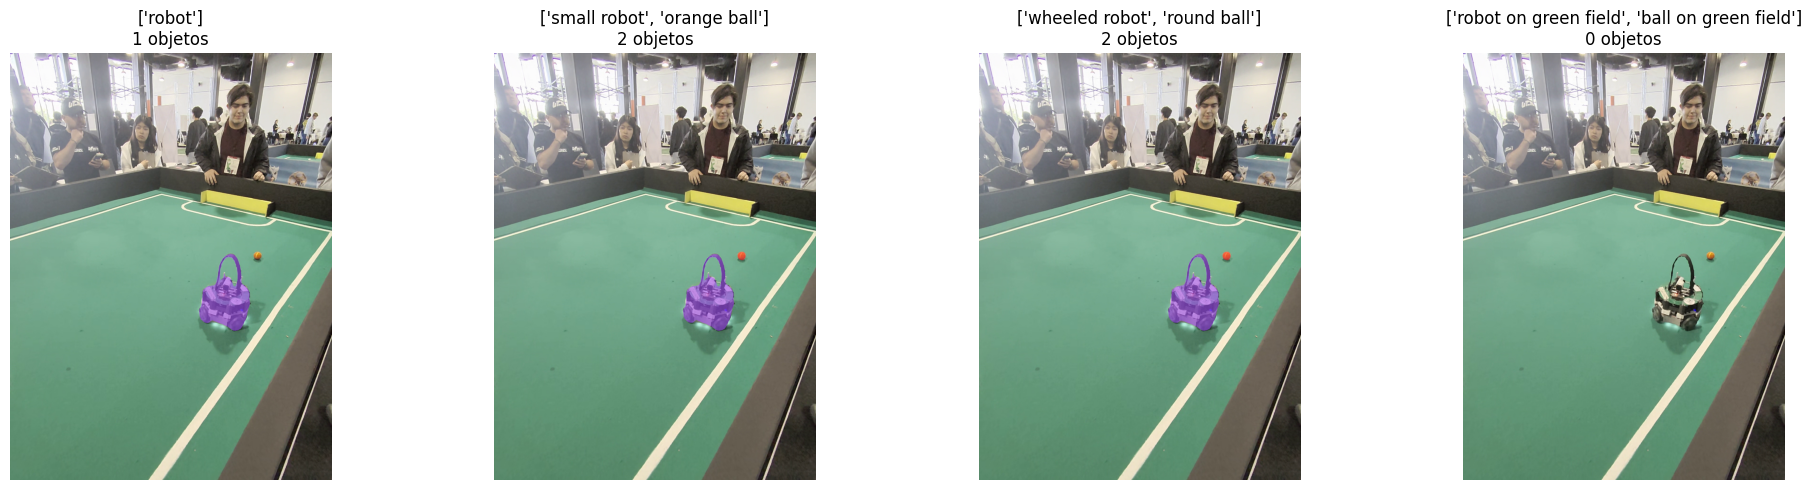

In [29]:
# Probar distintos prompts en el mismo frame donde falla
frame_falla = None
cap = cv2.VideoCapture("../VideosEjemplo/gael.mov")

cap.set(cv2.CAP_PROP_POS_FRAMES, 400)  
ret, frame_falla = cap.read()
cap.release()

prompts_a_probar = [
    ["robot"],
    ["small robot", "orange ball"],
    ["wheeled robot", "round ball"],
    ["robot on green field", "ball on green field"],
]

fig, axes = plt.subplots(1, len(prompts_a_probar), figsize=(20, 5))

for i, prompt in enumerate(prompts_a_probar):
    predictor_video.set_image(frame_falla)
    res = predictor_video(text=prompt)[0]
    det = sv.Detections.from_ultralytics(res)
    
    annotated = mask_annotator.annotate(scene=frame_falla.copy(), detections=det)
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"{prompt}\n{len(det)} objetos")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Aplicando Yolo para segmentar mejor los robots

In [35]:
mask_annotator  = sv.MaskAnnotator(opacity=0.5)
box_annotator   = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator()

tracker = sv.ByteTrack()
CLASES_INTERES = None
CLASES_EXCLUIR = [0] 

In [38]:
def procesar_frame_yolo_sam(frame: np.ndarray, _: int) -> np.ndarray:
    
    # ── Paso 1: YOLO ──────────────────────────────────────────────────────────
    yolo_results = yolo_model(frame, verbose=False)[0]
    yolo_det = sv.Detections.from_ultralytics(yolo_results)
    yolo_det = yolo_det[~np.isin(yolo_det.class_id, CLASES_EXCLUIR)]
    
    if len(yolo_det) == 0:
        return frame
    
    # ── Paso 2: SAM 3 ─────────────────────────────────────────────────────────
    bboxes = yolo_det.xyxy.tolist()
    
    try:
        sam_results = sam_model(frame, bboxes=bboxes, verbose=False)[0]
        sam_det = sv.Detections.from_ultralytics(sam_results)
    except Exception:
        sam_det = sv.Detections.empty()  # ← detecciones vacías seguras
    
    # ── Paso 3: Decidir qué usar ──────────────────────────────────────────────
    yolo_det = tracker.update_with_detections(yolo_det)
    
    # SAM 3 válido solo si devolvió el mismo número de objetos que YOLO
    usar_sam = sam_det is not None and len(sam_det) == len(yolo_det) and len(sam_det) > 0
    
    det_final = sam_det if usar_sam else yolo_det

    # Heredar metadata de YOLO siempre
    det_final.tracker_id = yolo_det.tracker_id
    det_final.class_id   = yolo_det.class_id
    det_final.confidence = yolo_det.confidence

    # ── Paso 4: Anotar ────────────────────────────────────────────────────────
    labels = [
        f"ID:{tid} | {yolo_results.names[cid]}"
        for tid, cid in zip(det_final.tracker_id, det_final.class_id)
    ] if det_final.tracker_id is not None else []

    if usar_sam:
        annotated = mask_annotator.annotate(scene=frame.copy(), detections=det_final)
    else:
        annotated = box_annotator.annotate(scene=frame.copy(), detections=det_final)
    
    if labels:
        annotated = label_annotator.annotate(scene=annotated, detections=det_final, labels=labels)
    
    annotated = trace_annotator.annotate(scene=annotated, detections=det_final)
    
    return annotated


# ── Procesar video completo
sv.process_video(
    source_path=video_path,
    target_path="assets/yolo_sam_pipeline.mp4",
    callback=procesar_frame_yolo_sam
)
print("Guardado: assets/yolo_sam_pipeline.mp4")
print(yolo_model.names)  # diccionario {id: nombre}

WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must

## Otra forma de verlo aplicando los conocimientos del notebook 7

In [1]:
# !pip install supervision ultralytics
import supervision as sv
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics import YOLO, SAM
import torch
import cv2
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path
import numpy as np

Path("assets").mkdir(exist_ok=True)

frame_falla = None
cap = cv2.VideoCapture("../VideosEjemplo/gael.mov")

cap.set(cv2.CAP_PROP_POS_FRAMES, 380)  
ret, frame_falla = cap.read()
cap.release()

print(f"Imagen cargada: {frame_falla.shape}")

c:\Users\IGNITER\anaconda3\envs\supervision\Lib\site-packages\supervision\annotators\core.py:11: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.interpolate import splev, splprep


Imagen cargada: (1808, 1360, 3)


In [2]:
overrides = dict(conf=0.15, task="segment", mode="predict", model="sam3.pt")
if torch.cuda.is_available():
    overrides["half"] = True   # FP16 solo en GPU

predictor = SAM3SemanticPredictor(overrides=overrides)
print("Predictor listo")

Predictor listo


In [3]:
predictor.set_image(image=frame_falla)

resultados = predictor(text=["little robot", "Robot", "little robot white"])[0]
detections = sv.Detections.from_ultralytics(resultados)

label_annotator = sv.LabelAnnotator()
box_annotator   = sv.BoxAnnotator()

print(f"Objetos encontrados: {len(detections)}")
print(f"¿Tiene máscaras?    {detections.mask is not None}")

Ultralytics 8.4.56  Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050, 8151MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 little robot, 4 Robots, 1 little robot white, 592.8ms
Speed: 3.9ms preprocess, 592.8ms inference, 76.0ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-21
Objetos encontrados: 6
¿Tiene máscaras?    True


WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 little robot, 78.3ms
Speed: 3.3ms preprocess, 78.3ms inference, 1.7ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-21
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 4 Robots, 79.2ms
Speed: 3.3ms preprocess, 79.2ms inference, 1.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-21
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 little robot white, 77.9ms
Speed: 2.9ms preprocess, 77.9ms inference, 2.2ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-21
WARNING imgsz=[640] must 

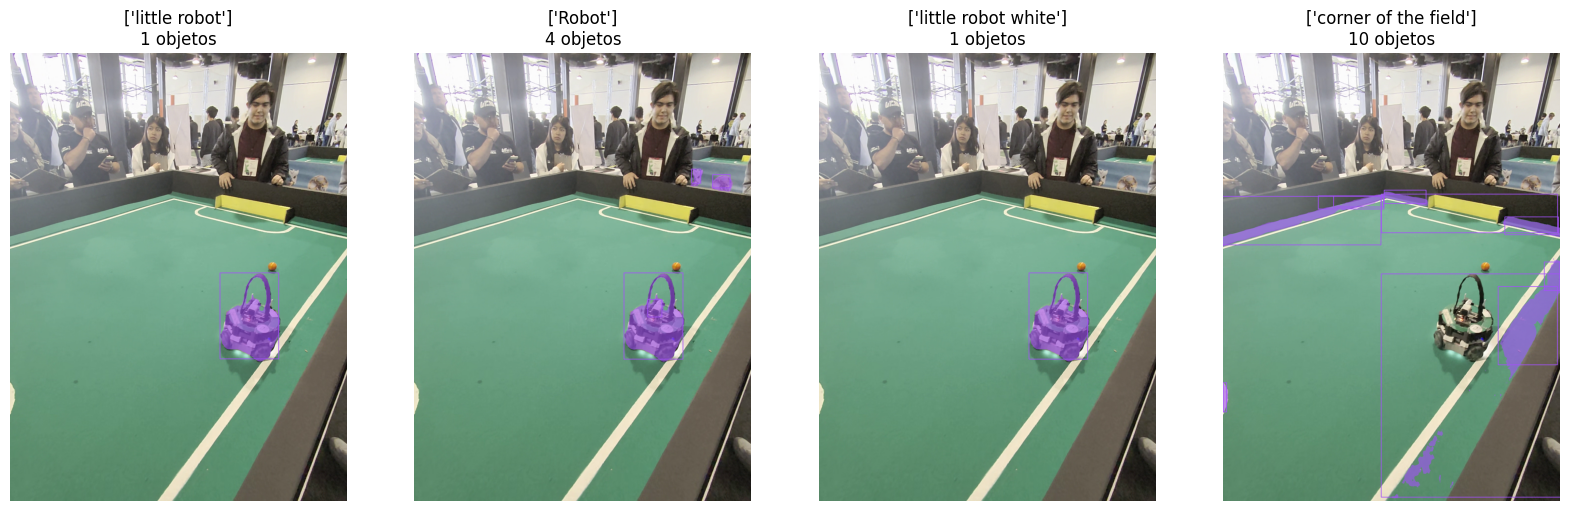

In [13]:
box_annotator  = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator(opacity=0.6)

fig, axes = plt.subplots(1, 4, figsize=(20, 10))
for ax, prompt in zip(axes, [["little robot"], ["Robot"], ["little robot white"], ["corner of the field"]]):
    predictor.set_image(image=frame_falla)
    res = predictor(text=prompt)[0]
    det = sv.Detections.from_ultralytics(res)
    
    annotated = mask_annotator.annotate(scene=frame_falla.copy(), detections=det)
    annotated = box_annotator.annotate(scene=annotated, detections=det)
    
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{prompt}\n{len(det)} objetos")
    ax.axis("off")

## Procesamos el video con esto

In [55]:
import warnings
warnings.filterwarnings("ignore")

predictor.args.conf = 0.10  # bajar umbral para intentar detectar el robot
tracker = sv.ByteTrack()
tracker.reset()

def procesar_frame_sam(frame: np.ndarray, _: int) -> np.ndarray:
    
    # Segmentar frame actual
    predictor.set_image(frame)
    resultados_frame = predictor(text=["little robot", "orange ball"])[0]
    detections = sv.Detections.from_ultralytics(resultados_frame)

    if len(detections) == 0:
        return frame

    detections = tracker.update_with_detections(detections)
    
    labels = [
        f"ID:{tid}" for tid in detections.tracker_id
    ] if detections.tracker_id is not None else []

    annotated = mask_annotator.annotate(scene=frame.copy(), detections=detections)
    annotated = box_annotator.annotate(scene=annotated, detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    return annotated

# ← cambia el nombre cada prueba: v1, v2, v3...
sv.process_video(
    source_path="../VideosEjemplo/gael.mov",
    target_path="assets/prueba_v3.mp4",
    callback=procesar_frame_sam
)
print("Listo")

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 2 little robots, 2 orange balls, 88.7ms
Speed: 3.2ms preprocess, 88.7ms inference, 2.6ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-20
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 2 little robots, 2 orange balls, 88.0ms
Speed: 3.6ms preprocess, 88.0ms inference, 2.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-20
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 2 little robots, 2 orange balls, 88.5ms
Speed: 3.3ms preprocess, 88.5ms inference, 2.5ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebook

In [54]:
predictor.args.conf = 0.50
tracker = sv.ByteTrack()
tracker.reset()

# Memoria de últimas detecciones válidas
ultima_deteccion_valida = None
frames_sin_deteccion = 0
MAX_FRAMES_SIN_DETECCION = 15  # cuántos frames máximo interpolamos

def procesar_frame_sam(frame: np.ndarray, _: int) -> np.ndarray:
    global ultima_deteccion_valida, frames_sin_deteccion

    predictor.set_image(frame)
    resultados_frame = predictor(text=["little robot", "orange ball"])[0]
    detections = sv.Detections.from_ultralytics(resultados_frame)

    # Filtrar ruido
    if detections.confidence is not None:
        detections = detections[detections.confidence >= 0.50]

    if len(detections) > 0:
        # SAM detectó algo — actualizar memoria
        detections = tracker.update_with_detections(detections)
        ultima_deteccion_valida = detections
        frames_sin_deteccion = 0
    else:
        # SAM no detectó nada
        frames_sin_deteccion += 1
        
        if ultima_deteccion_valida is not None and frames_sin_deteccion <= MAX_FRAMES_SIN_DETECCION:
            # Usar última detección conocida como respaldo
            detections = ultima_deteccion_valida
        else:
            # Demasiados frames sin detección — devolver frame limpio
            return frame

    if len(detections) == 0:
        return frame

    labels = [
        f"ID:{tid} ({conf:.0%})"
        for tid, conf in zip(detections.tracker_id, detections.confidence)
    ] if detections.tracker_id is not None else []

    annotated = mask_annotator.annotate(scene=frame.copy(), detections=detections)
    annotated = box_annotator.annotate(scene=annotated, detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    return annotated

sv.process_video(
    source_path="../VideosEjemplo/gael.mov",
    target_path="assets/prueba_v6.mp4",
    callback=procesar_frame_sam
)
print("✓ Listo")

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 orange ball, 83.9ms
Speed: 3.8ms preprocess, 83.9ms inference, 1.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-20
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 orange ball, 83.6ms
Speed: 2.8ms preprocess, 83.6ms inference, 2.0ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-20
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

0: 644x644 1 orange ball, 85.2ms
Speed: 3.1ms preprocess, 85.2ms inference, 2.1ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\IGNITER\Desktop\CopaFutBotMx\SupervisionVideo\Copa-FutBotMX\notebooks\runs\segment\predict-20
WARNING imgsz=[640] must be 